In [19]:
from misc import *
import constant

In [20]:
def set_size(w,h, ax=None):
    """ w, h: width, height in inches """
    if not ax: ax=plt.gca()
    l = ax.figure.subplotpars.left
    r = ax.figure.subplotpars.right
    t = ax.figure.subplotpars.top
    b = ax.figure.subplotpars.bottom
    figw = float(w)/(r-l)
    figh = float(h)/(t-b)
    ax.figure.set_size_inches(figw, figh)

In [21]:
# upto 5 long track candidates isMuon
LTRACK5_FILE_PATH = "/dice/projects/LHCb_PbPb_MSCi/isMuon_Tr1_5_B2JpsiK_PbPb/LeadLead_B2JpsiKTuple_all.root"
DEFAULT_TREE_NAME = "B2JpsiKTuple/DecayTree"

# All 3 long track candidates
LTRACK3_FILE_PATH = "/dice/projects/LHCb_PbPb_MSCi/isMuon_PbPb_B2JpsiK/isMuon.root"

df = load_root(LTRACK5_FILE_PATH, DEFAULT_TREE_NAME)
df_3ltracks = load_root(LTRACK3_FILE_PATH, DEFAULT_TREE_NAME)

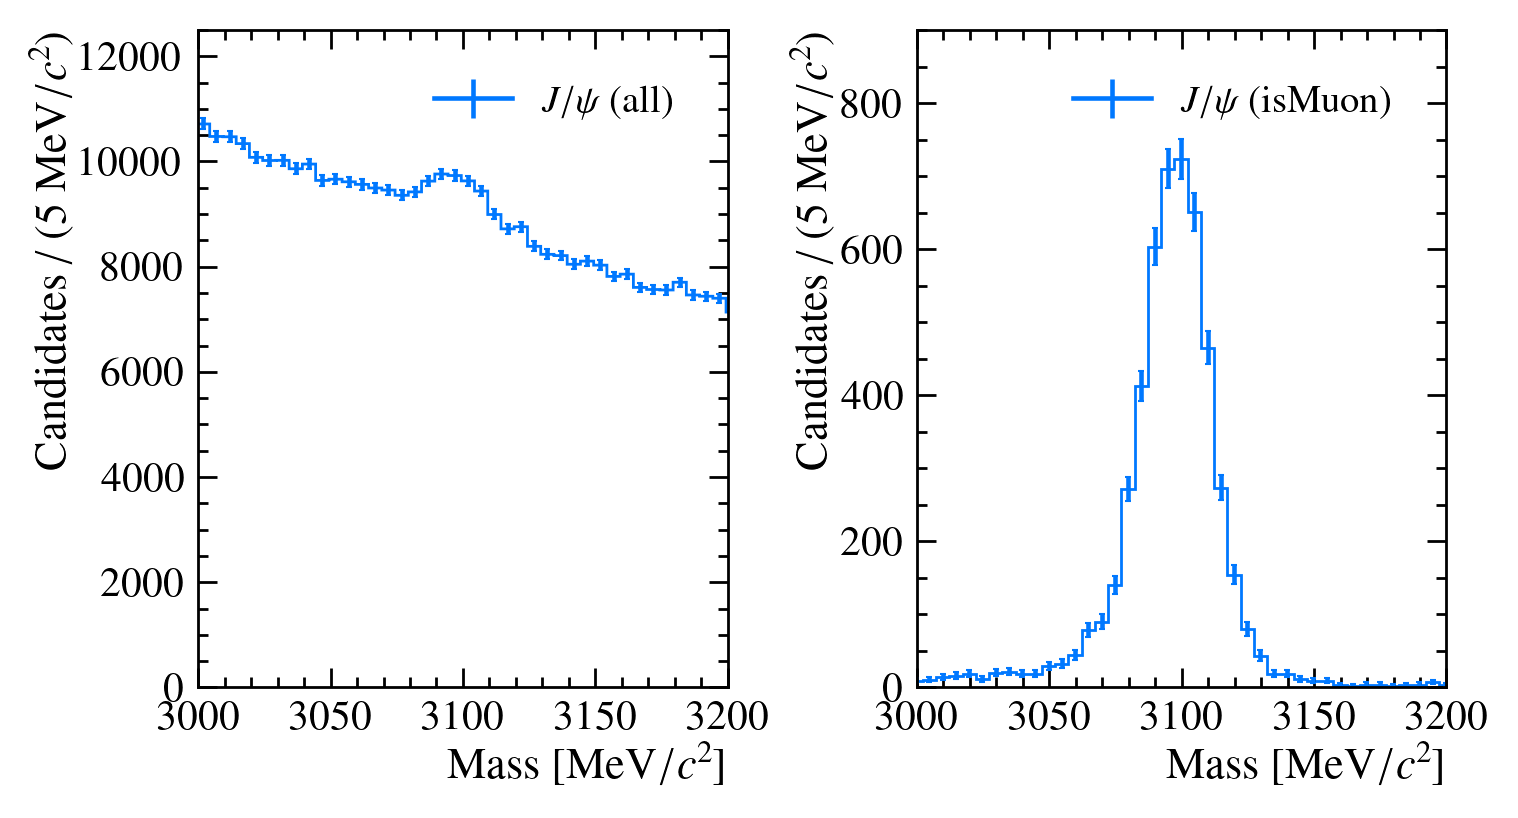

In [22]:
all_jpsi_series = pd.read_csv("data/all_jpsi_data_3ltracks.csv")["J_psi_1S_M"]
ismuon_jpsi_series = df_3ltracks["J_psi_1S_M"]

fig_jpsi, (ax1_jpsi, ax2_jpsi) = plt.subplots(1, 2, figsize=(5*3, 4*2))

histogram_ax(
    [HistogramPlot(all_jpsi_series, r"$J/\psi$ (all)", True, 5)],
    ax1_jpsi,
    xlabel=r"Mass",
    xlim=[3000, 3200],
    ylim=[0,12500],
    unit_tex=r"\mathrm{MeV}/c^2"
)

histogram_ax(
    [HistogramPlot(ismuon_jpsi_series, r"$J/\psi$ (isMuon)", True, 5)],
    ax2_jpsi,
    xlabel=r"Mass",
    xlim=[3000, 3200],
    ylim=[0,900],
    unit_tex=r"\mathrm{MeV}/c^2"
)
fig_jpsi.savefig("jpsi_ismuon.svg")

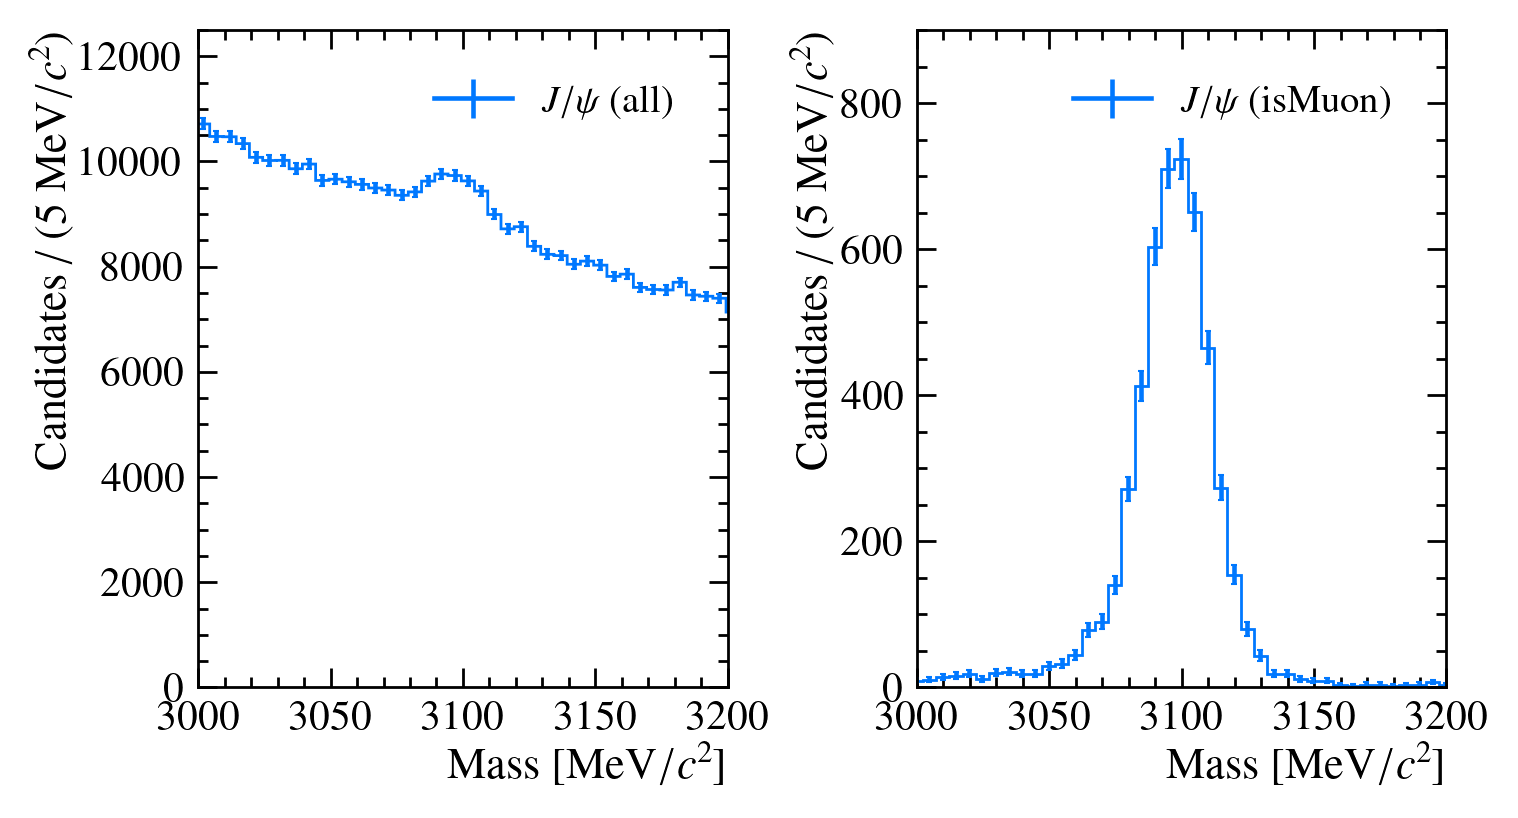

In [23]:
all_jpsi_series = pd.read_csv("data/all_jpsi_data_3ltracks.csv")["J_psi_1S_M"]
ismuon_jpsi_series = df_3ltracks["J_psi_1S_M"]

fig_jpsi, (ax1_jpsi, ax2_jpsi) = plt.subplots(1, 2, figsize=(5*3, 4*2))

histogram_ax(
    [HistogramPlot(all_jpsi_series, r"$J/\psi$ (all)", True, 5)],
    ax1_jpsi,
    xlabel=r"Mass",
    xlim=[3000, 3200],
    ylim=[0,12500],
    unit_tex=r"\mathrm{MeV}/c^2"
)

histogram_ax(
    [HistogramPlot(ismuon_jpsi_series, r"$J/\psi$ (isMuon)", True, 5)],
    ax2_jpsi,
    xlabel=r"Mass",
    xlim=[3000, 3200],
    ylim=[0,900],
    unit_tex=r"\mathrm{MeV}/c^2"
)
fig_jpsi.savefig("jpsi_ismuon.svg")

In [24]:
df = df[df["Kplus_isMuon"] == False]
jpsi_cut_df = df[(constant.JPSI_MASS-65 <= df["J_psi_1S_M"]) & (df["J_psi_1S_M"] <= constant.JPSI_MASS+65)]
print(len(jpsi_cut_df))

14833


# nVelo

In [25]:
nvelo3_df = jpsi_cut_df[jpsi_cut_df["nVeloTracks"] >= 3]
nvelo5_df = jpsi_cut_df[jpsi_cut_df["nVeloTracks"] >= 5]
nvelo7_df = jpsi_cut_df[jpsi_cut_df["nVeloTracks"] >= 7]
nvelo9_df = jpsi_cut_df[jpsi_cut_df["nVeloTracks"] >= 9]

[4.6288684346318405,
 7.134251102910639,
 7.3730050820104225,
 9.564417355870319,
 9.930700735751998,
 11.181218129330773,
 17.66215713708789,
 20.58035348419162,
 29.459428790509264,
 34.18350431990439,
 38.27433024077618,
 40.70116032495844,
 43.384536414730974,
 43.41979940377951,
 49.4779893518089,
 56.76825659054248,
 58.28500481996889,
 60.85006881670597,
 63.35058737646068,
 65.59147877846317,
 71.69262554986562,
 71.71748750533789,
 74.79554588160681,
 74.86828008784414,
 74.98581354518501,
 75.29330676687641,
 75.72384959302781,
 76.38859779285394,
 81.96630760671542,
 82.15953821837138,
 86.05748671299261,
 87.76272215588142,
 95.92153149407477,
 97.07647196983635,
 102.35043753159152,
 102.40148840783604,
 103.89643569015061,
 112.83724160308338,
 114.85615140248046,
 115.37100475805073,
 115.60733385964977,
 116.12325674167005,
 117.41069245303788,
 124.96930044376859,
 130.23176025906923,
 131.419603030914,
 133.68088348587116,
 134.01354983031797,
 137.6987866371901,
 137

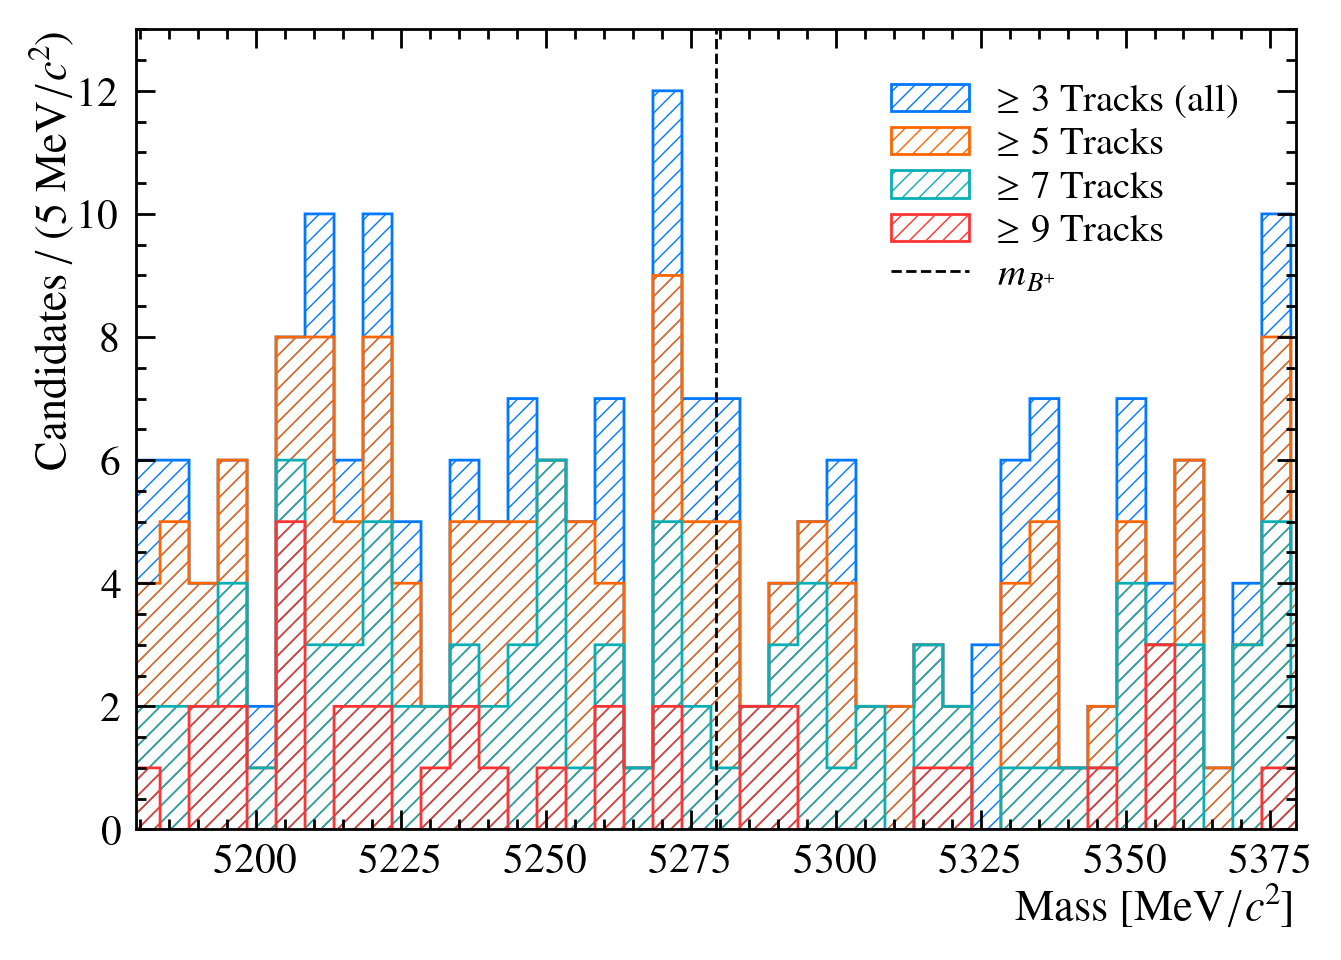

In [31]:
fig_velo, ax_velo = plt.subplots(layout="constrained")
# ax_velo.axvspan(constant.BPLUS_MASS-8, constant.BPLUS_MASS+8, color="lightgrey", alpha=0.4)


nvelo3_hist_plt = HistogramPlot(
    nvelo3_df["Bplus_M"], r"$\geq 3$ Tracks (all)", False, 5, hatch="//",
)

histogram_ax(
    [
        nvelo3_hist_plt,
        HistogramPlot(
            nvelo5_df["Bplus_M"],
            r"$\geq 5$ Tracks",
            False,
            nvelo3_hist_plt.bin_edges,
            hatch="//",
        ),          
        HistogramPlot(
            nvelo7_df["Bplus_M"],
            r"$\geq 7$ Tracks",
            False,
            nvelo3_hist_plt.bin_edges,
            hatch="//",
        ),
        HistogramPlot(
            nvelo9_df["Bplus_M"],
            r"$\geq 9$ Tracks",
            False,
            nvelo3_hist_plt.bin_edges,
            hatch="//",
        ),
    ],
    ax_velo,
    ylim=[0, 13],
    xlabel=r"Mass",
    unit_tex=r"\mathrm{MeV}/c^2",
    xlim=[constant.BPLUS_MASS - 100, constant.BPLUS_MASS + 100],
)
ax_velo.axvline(constant.BPLUS_MASS, color="k", linewidth=2, label=r"$m_{B^+}$", ls="--")
ax_velo.legend()

set_size(10, 7, ax=ax_velo)
fig_velo.savefig("nvelo.svg")

sorted(abs(constant.BPLUS_MASS - nvelo9_df["Bplus_M"]))

# PIDK

len(jpsi_cut_df)=14833 len(pidk_df)=2400


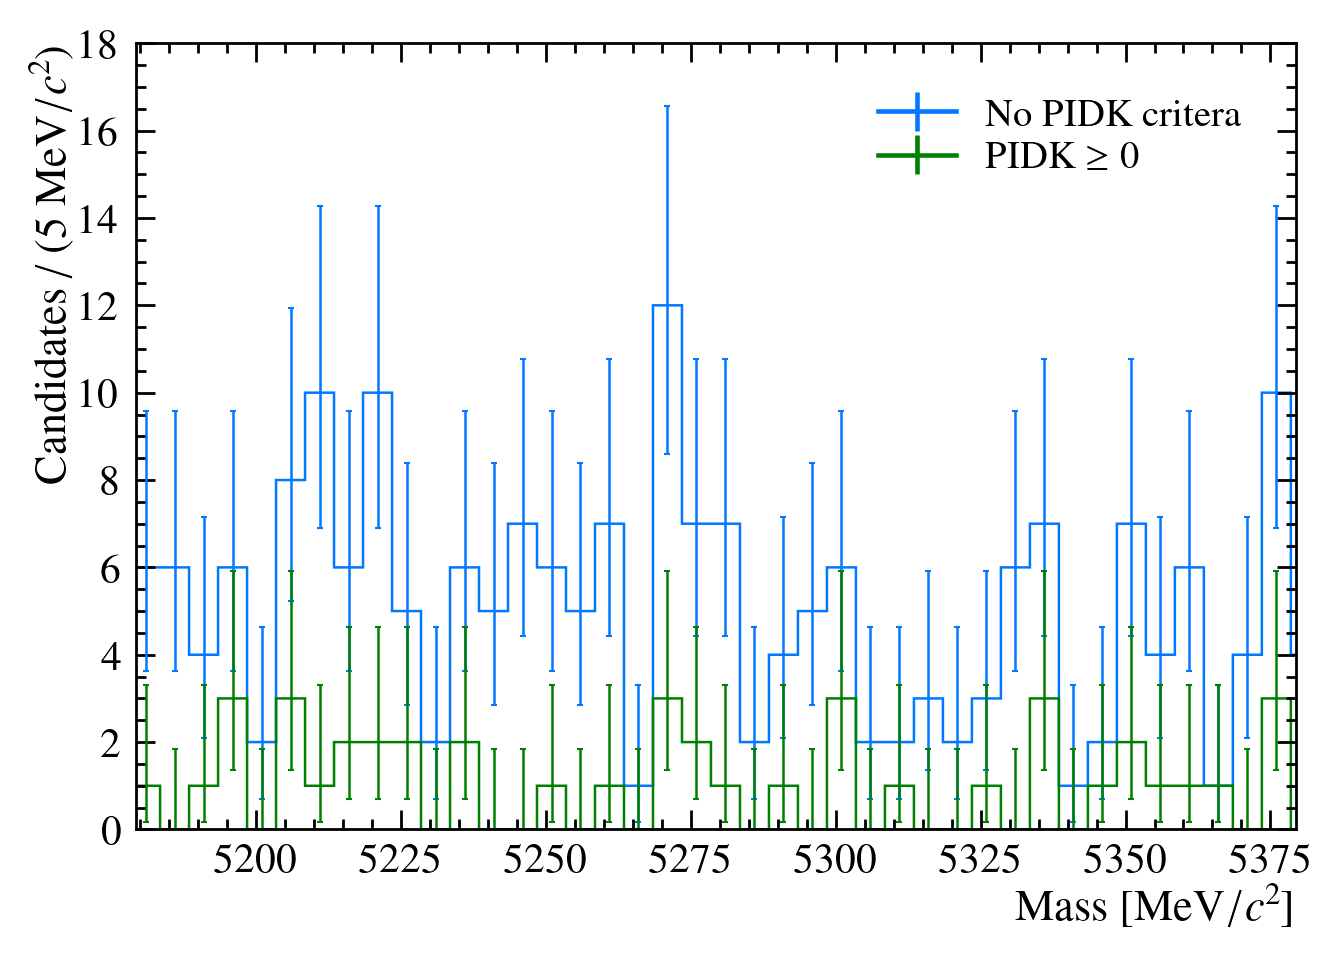

In [27]:
# just require K is more likely than pi
pidk_df = jpsi_cut_df[jpsi_cut_df["Kplus_PIDK"] > 0]

fig_pidk, ax_pidk = plt.subplots(layout="constrained")
set_size(10, 7, ax=ax_pidk)


Bplus_plot = HistogramPlot(
    jpsi_cut_df["Bplus_M"], "No PIDK critera", True, 5, lw=1.8,
)

histogram_ax(
    [
        Bplus_plot,
        HistogramPlot(
            pidk_df["Bplus_M"], r"PIDK $\geq 0$", True, Bplus_plot.bin_edges, lw=1.8, color="g"
        ),
    ],
    ax_pidk,
    xlim=[constant.BPLUS_MASS - 100, constant.BPLUS_MASS + 100],
    ylim=[0, 18],
    unit_tex=r"\mathrm{MeV}/c^2",
    xlabel="Mass",
)
# ax_pidk.axvline(constant.BPLUS_MASS, color="k", linewidth=2, label=r"$m_{B^+}$", ls="--")
# ax_pidk.legend()

print(f"{len(jpsi_cut_df)=} {len(pidk_df)=}")

# set_size(10, 7, ax=ax_velo)
fig_pidk.savefig("figures/Report/pidk.svg")

Histogram not saved to file


(<Figure size 1200x900 with 1 Axes>, <Axes: ylabel='Candidates / 300'>)

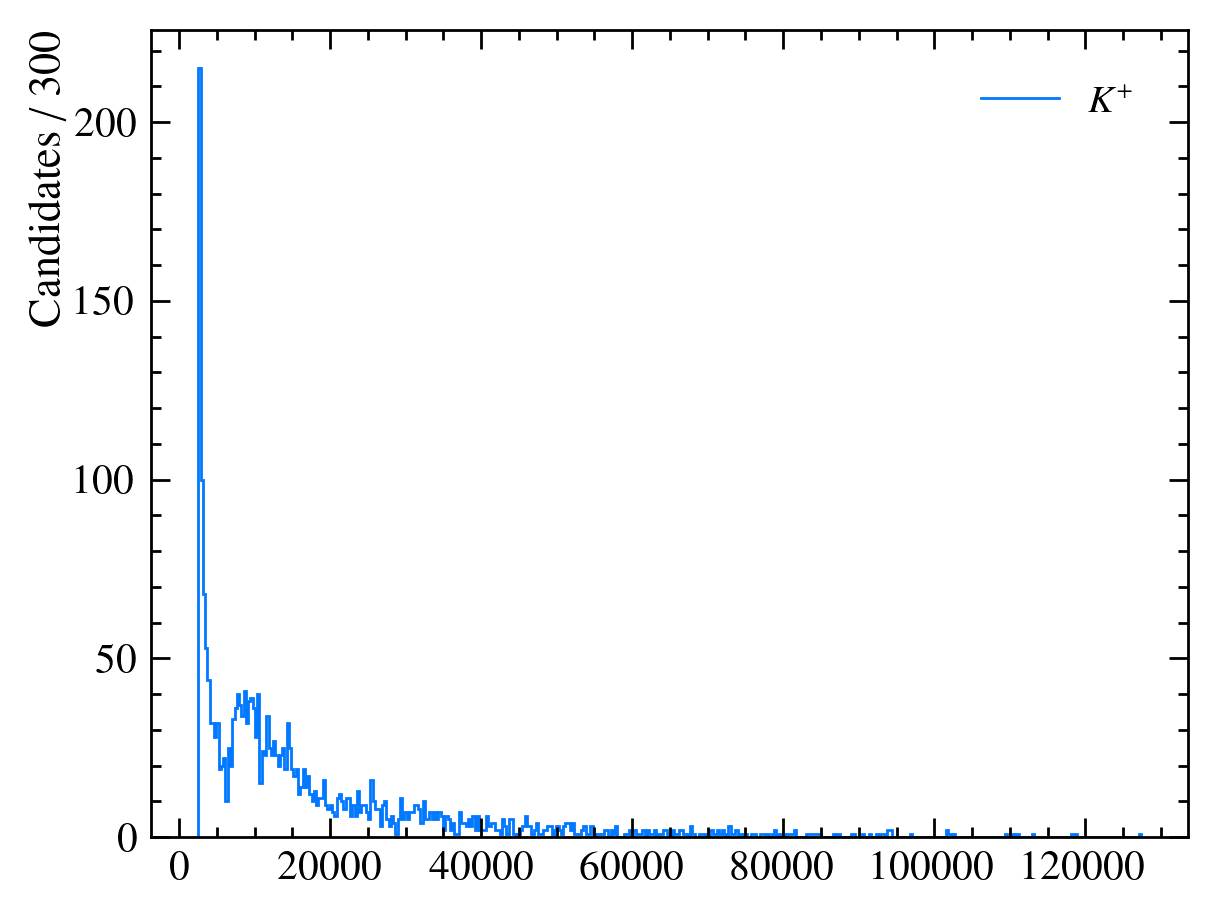

In [28]:
histogram_fig(
    [HistogramPlot(pidk_df["Kplus_P"], "$K^+$", False, 300)],
    False,
    # xlim=[0,10000]
)